In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [4]:
df = pd.read_csv('Flight_Status.txt')

In [5]:
df.head()

,Temperature,Wind Speed,Humidity,Flight Status
0,32.5,10.2,45.3,Fly
1,28.4,12.1,60.2,Fly
2,34.1,8.3,50.0,Fly
3,19.3,20.5,85.1,Don't Fly
4,5.7,35.8,90.2,Don't Fly


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    131 non-null    float64
 1   Wind Speed     131 non-null    float64
 2   Humidity       131 non-null    float64
 3   Flight Status  131 non-null    object 
dtypes: float64(3), object(1)
memory usage: 4.2+ KB


<Axes: xlabel='Flight Status', ylabel='count'>

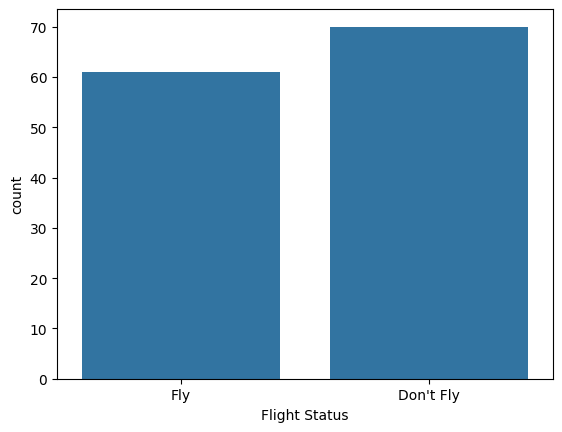

In [7]:
sns.countplot(x="Flight Status", data=df)

<Axes: xlabel='Flight Status', ylabel='Wind Speed'>

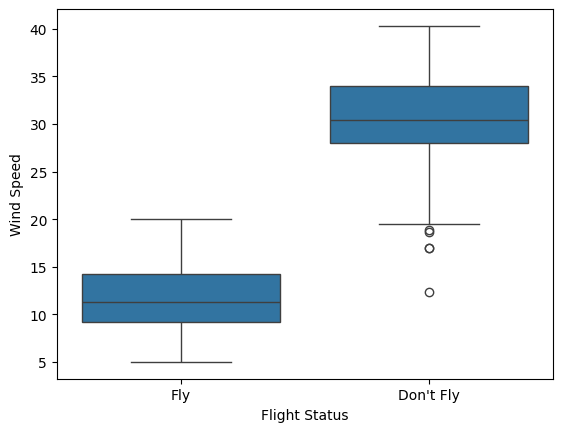

In [8]:
sns.boxplot(x='Flight Status',y='Wind Speed',data=df)

In [9]:
label_encoder = LabelEncoder()
df['Flight Status'] = label_encoder.fit_transform(df['Flight Status'])

In [10]:
# Get the mapping of labels to encoded values
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Print the label mapping
print("Label Encoding Mapping:")
for label, encoded in label_mapping.items():
    print(f"{label}: {encoded}")

Label Encoding Mapping:
Don't Fly: 0
Fly: 1


In [11]:
# Features and target variable
X = df[['Temperature', 'Wind Speed', 'Humidity']]  # Features
y = df['Flight Status']  # Target

In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial')

In [14]:
y_pred = model.predict(X_test_scaled)

In [15]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')
print('Confusion Matrix:')
print(conf_matrix)

Accuracy: 100.00%
Confusion Matrix:
[[12  0]
 [ 0 15]]


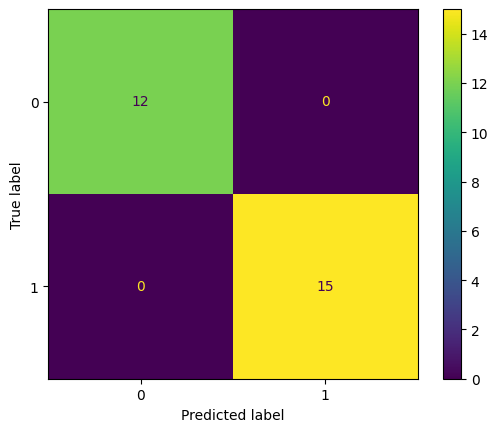

In [16]:
#Graphical Display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [17]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(scores)
print("Mean CV Accuracy:", scores.mean())

[1.         1.         1.         0.95238095 1.        ]
Mean CV Accuracy: 0.9904761904761905


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

In [18]:
import pickle

with open('flight_status_model.pkl','wb') as f:
  pickle.dump(model ,f)

with open('flight_status_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [19]:
with open('flight_status_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Example input: wind speed = 20 km/h, temperature = 30°C, humidity = 50%
new_data = np.array([[20, 30, 60]])

# If you applied scaling before training, apply it here too
new_data_scaled = scaler.transform(new_data)

prediction = loaded_model.predict(new_data_scaled)
print("Flight Status:", "Fly" if prediction[0] == 1 else "Don't Fly")

Flight Status: Fly


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
!pip install gradio

In [21]:
# Load the trained model
with open('flight_status_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the scaler
with open('flight_status_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

In [22]:
# Prediction function
def predict_flight_status(wind_speed, temperature, humidity):
    new_data = np.array([[wind_speed, temperature, humidity]])
    new_data_scaled = scaler.transform(new_data)
    prediction = model.predict(new_data_scaled)

    result = "✅ Flight Status: Fly" if prediction[0] == 1 else "❌ Flight Status: Don't Fly"

    return result, new_data.tolist(), new_data_scaled.tolist(), prediction.tolist()

In [23]:
# Gradio interface
import gradio as gr

demo = gr.Interface(
    fn=predict_flight_status,
    inputs=[
        gr.Slider(0, 100, value=20, label="Wind Speed (km/h)"),
        gr.Slider(-10, 50, value=25, label="Temperature (°C)"),
        gr.Slider(0, 100, value=50, label="Humidity (%)"),
    ],
    outputs=[
        gr.Text(label="Prediction"),
        gr.JSON(label="Raw Input"),
        gr.JSON(label="Scaled Input"),
        gr.JSON(label="Prediction Output"),
    ],
    title="Flight Status Predictor ✈️",
    description="Predict whether it's safe to fly based on wind speed, temperature, and humidity."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b0e05960a5a5563dbc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
